In [ ]:
import torch
from torch.utils.data import Dataset
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2

from waymo_open_dataset.protos import end_to_end_driving_data_pb2 as wod_e2ed_pb2
from waymo_open_dataset import dataset_pb2 as open_dataset
from waymo_open_dataset.wdl_limited.camera.ops import py_camera_model_ops
from waymo_open_dataset.protos import end_to_end_driving_data_pb2 as wod_e2ed_pb2
from waymo_open_dataset.protos import end_to_end_driving_submission_pb2 as wod_e2ed_submission_pb2

2026-03-12 11:28:12.242571: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 11:28:12.275263: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-12 11:28:12.447694: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 11:28:13.161890: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [33]:
class WaymoE2EDataset(Dataset):
    def __init__(self, tfrecord_files, transform=None):
        self.filenames = tf.io.matching_files(tfrecord_files)
        self.transform = transform
        self.examples = []
        for f in self.filenames:
            dataset = tf.data.TFRecordDataset(f)
            self.examples.extend(list(dataset.as_numpy_iterator()))

    def __len__(self):
        return len(self.examples)
    
    def __getitem__(self, idx):
        bytes_example = self.examples[idx]
        data = wod_e2ed_pb2.E2EDFrame()
        data.ParseFromString(bytes_example)

        image = self.return_front3_cameras(data)
        if image is None:
            raise ValueError("No front camera image found")
        
        if self.transform:
            image = self.transform(image)

        waypoints = np.stack([
            data.future_states.pos_x,
            data.future_states.pos_y,
        ], axis=1).astype(np.float32)

        return image, waypoints

    def return_center_camera(self, data: wod_e2ed_pb2.E2EDFrame):
        for index, image_content in enumerate(data.frame.images):
            if image_content.name == 1:
                image = tf.io.decode_image(image_content.image).numpy()
                return image
        return None

    def return_front3_cameras(self, data:wod_e2ed_pb2.E2EDFrame):
        image_list = []
        order = [2, 1, 3]
        for camera_name in order:
            for index, image_content in enumerate(data.frame.images):
                if image_content.name == camera_name:
                    image = tf.io.decode_image(image_content.image).numpy()
                    image_list.append(image)
                    break
        
        return image_list

In [34]:

DATASET_FOLDER = 'waymo_open_dataset'

TRAIN_FILES = os.path.join(DATASET_FOLDER, 'training_*.tfrecord*')
VALIDATION_FILES = os.path.join(DATASET_FOLDER, 'val_*.tfrecord*')
TEST_FILES = os.path.join(DATASET_FOLDER, 'test_*.tfrecord*')

data = WaymoE2EDataset(TRAIN_FILES)
i, w = data.__getitem__(0)

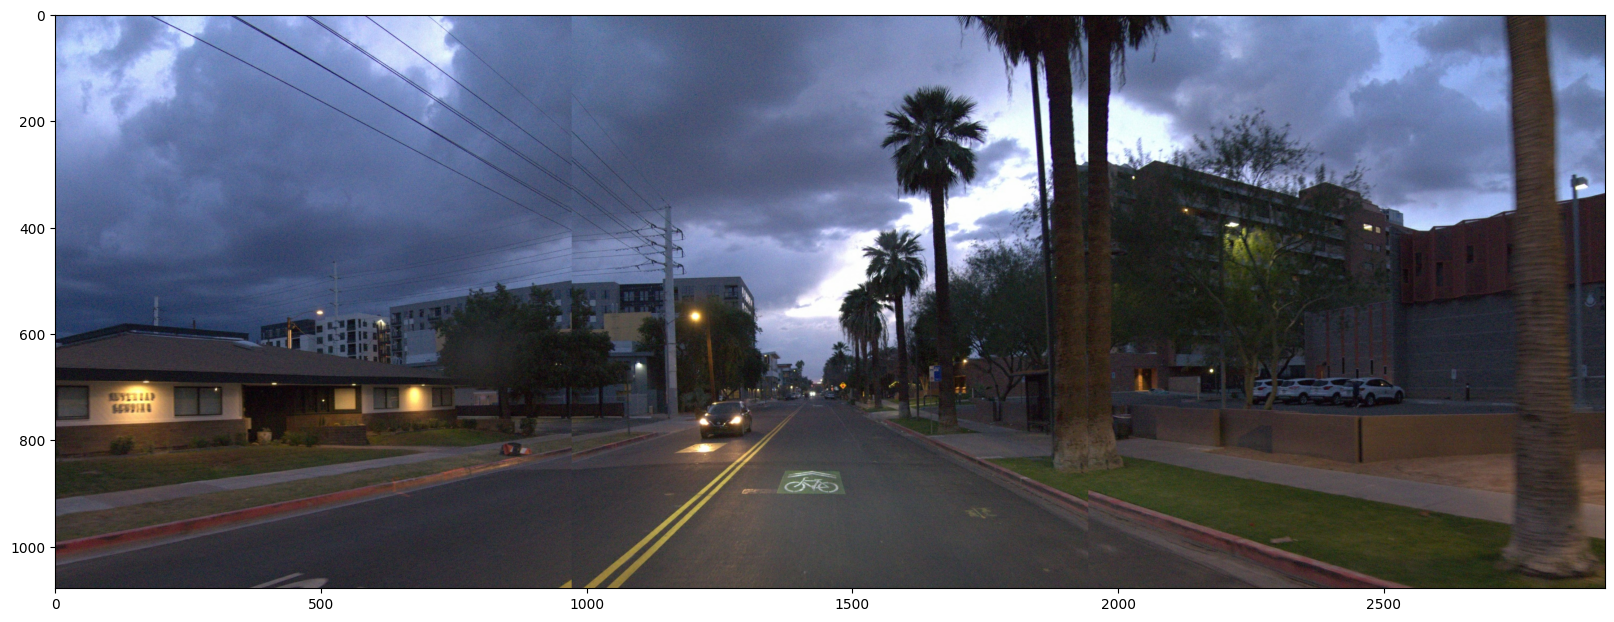

In [35]:
combined_image = np.concatenate(i, axis=1)
plt.figure(figsize=(20, 20))
plt.imshow(combined_image)

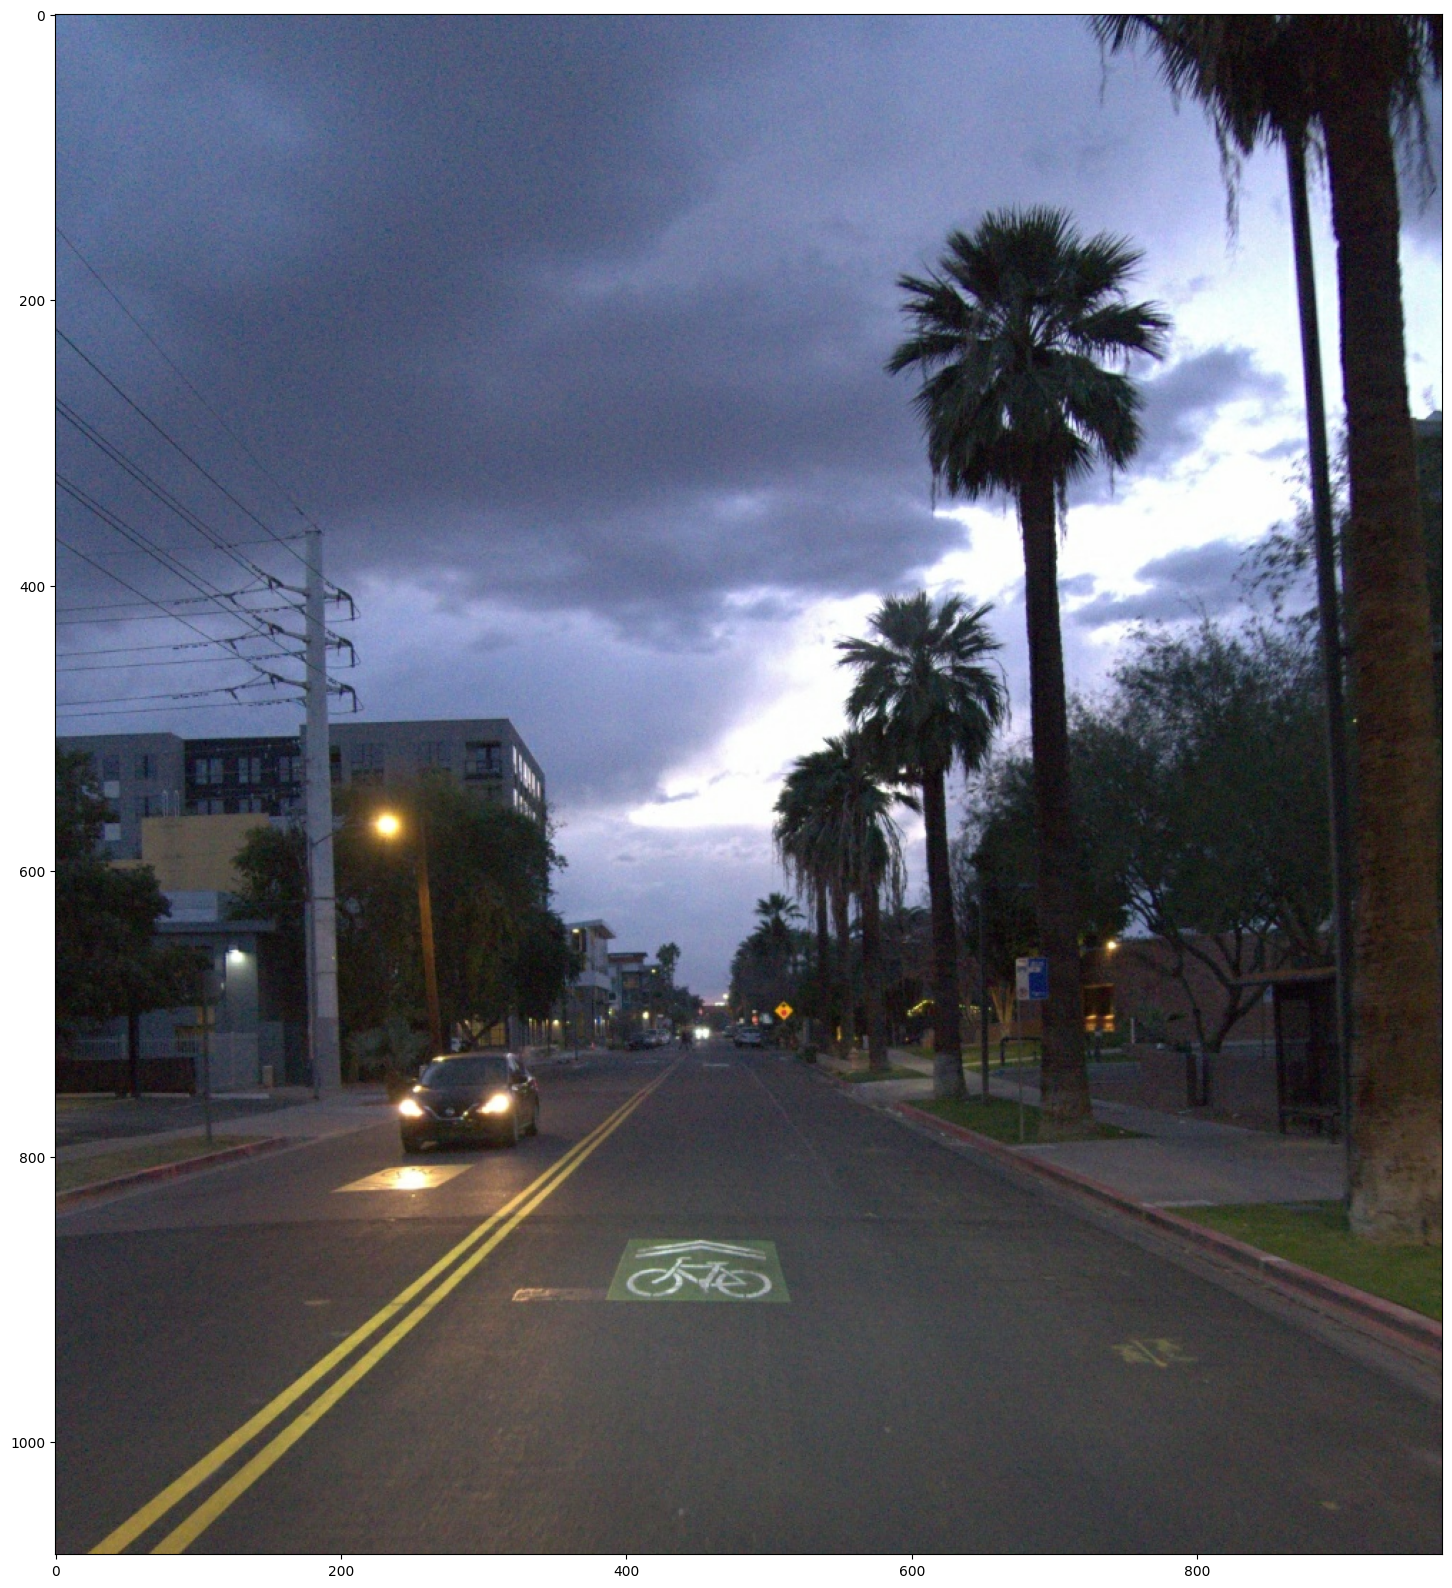

In [36]:
plt.figure(figsize=(20, 20))
plt.imshow(i[1])

[[2.0390625e+00 7.3242188e-03]
 [4.1132812e+00 1.8066406e-02]
 [6.1933594e+00 3.6621094e-02]
 [8.3007812e+00 5.8593750e-02]
 [1.0425781e+01 8.9843750e-02]
 [1.2582031e+01 1.2646484e-01]
 [1.4775391e+01 1.7089844e-01]
 [1.7005859e+01 2.2070312e-01]
 [1.9277344e+01 2.7978516e-01]
 [2.1570312e+01 3.4716797e-01]
 [2.3882812e+01 4.2138672e-01]
 [2.6197266e+01 5.0097656e-01]
 [2.8513672e+01 5.8544922e-01]
 [3.0818359e+01 6.7431641e-01]
 [3.3117188e+01 7.6123047e-01]
 [3.5410156e+01 8.4472656e-01]
 [3.7701172e+01 9.2333984e-01]
 [3.9992188e+01 9.9707031e-01]
 [4.2273438e+01 1.0639648e+00]
 [4.4548828e+01 1.1240234e+00]]


Text(0.5, 1.0, 'Future trajectory')

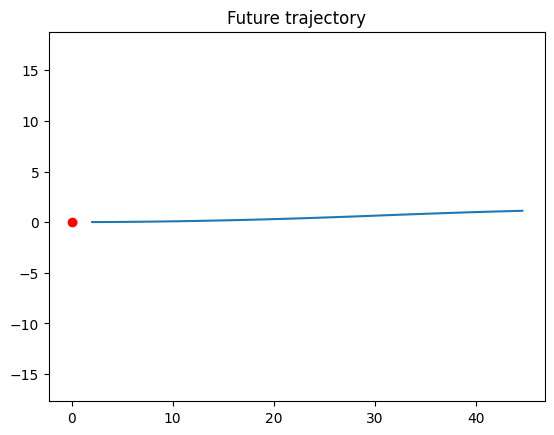

In [39]:
print(w)
plt.figure()
plt.plot(w[:,0], w[:,1])
plt.scatter(0,0,c="red")
plt.axis("equal")
plt.title("Future trajectory")